In [142]:
!pip install -q tsfresh prophet scikit-learn seaborn scipy shap


In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [159]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestRegressor

In [160]:
from scipy.stats import kurtosis, skew

In [161]:
from tsfresh import extract_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import EfficientFCParameters

In [162]:
from prophet import Prophet

In [ ]:
DATA_PATH = "/content/Clean.csv"
df = pd.read_csv(DATA_PATH)


df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


df['timestamp'] = pd.to_datetime(df['timestamp'])

df = df.sort_values(['person_id', 'timestamp']).reset_index(drop=True)

print(df.shape)
df.head()


(374, 17)


,person_id,gender,age,occupation,job_category,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,bmi_category,weight_category,systolic_blood_pressure,diastolic_blood_pressure,heart_rate,daily_steps,sleep_disorder,timestamp
0,1,Male,27,Software Engineer,Science and Technology,6.1,6,42,6,Overweight,2,126,83,77,4200,NaN,2025-03-08 11:12:00
1,2,Male,28,Doctor,Healthcare,6.2,6,60,8,Normal,1,125,80,75,10000,NaN,2025-04-13 17:14:00
2,3,Male,28,Doctor,Healthcare,6.2,6,60,8,Normal,1,125,80,75,10000,NaN,2025-07-26 10:59:00
3,4,Male,28,Sales Representative,Business Management,5.9,4,30,8,Obese,3,140,90,85,3000,Sleep Apnea,2025-01-27 16:17:00
4,5,Male,28,Sales Representative,Business Management,5.9,4,30,8,Obese,3,140,90,85,3000,Sleep Apnea,2025-01-29 03:46:00


In [164]:
ts_cols = [
    'heart_rate',
    'daily_steps',
    'sleep_duration',
    'stress_level'
]

meta_cols = [
    'gender', 'age', 'occupation', 'job_category',
    'bmi_category', 'weight_category', 'sleep_disorder'
]


In [165]:
df_encoded = df.copy()
le = LabelEncoder()

for col in meta_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))


In [167]:
stat_rows = []

for pid, g in df_encoded.groupby('person_id'):
    row = {'person_id': pid}
    for col in ts_cols:
        row[f'{col}_mean'] = g[col].mean()
        row[f'{col}_std'] = g[col].std()
        row[f'{col}_kurtosis'] = kurtosis(g[col])
        row[f'{col}_skewness'] = skew(g[col])
    stat_rows.append(row)

stat_features = pd.DataFrame(stat_rows)
stat_features.head()


,person_id,heart_rate_mean,heart_rate_std,heart_rate_kurtosis,heart_rate_skewness,daily_steps_mean,daily_steps_std,daily_steps_kurtosis,daily_steps_skewness,sleep_duration_mean,sleep_duration_std,sleep_duration_kurtosis,sleep_duration_skewness,stress_level_mean,stress_level_std,stress_level_kurtosis,stress_level_skewness
0,1,77.0,NaN,NaN,NaN,4200.0,NaN,NaN,NaN,6.1,NaN,NaN,NaN,6.0,NaN,NaN,NaN
1,2,75.0,NaN,NaN,NaN,10000.0,NaN,NaN,NaN,6.2,NaN,NaN,NaN,8.0,NaN,NaN,NaN
2,3,75.0,NaN,NaN,NaN,10000.0,NaN,NaN,NaN,6.2,NaN,NaN,NaN,8.0,NaN,NaN,NaN
3,4,85.0,NaN,NaN,NaN,3000.0,NaN,NaN,NaN,5.9,NaN,NaN,NaN,8.0,NaN,NaN,NaN
4,5,85.0,NaN,NaN,NaN,3000.0,NaN,NaN,NaN,5.9,NaN,NaN,NaN,8.0,NaN,NaN,NaN


In [168]:
tsfresh_input = df_encoded[['person_id', 'timestamp'] + ts_cols]

tsfresh_features = extract_features(
    tsfresh_input,
    column_id='person_id',
    column_sort='timestamp',
    default_fc_parameters=EfficientFCParameters(),
    n_jobs=0
)

impute(tsfresh_features)
print(tsfresh_features.shape)


Feature Extraction: 100%|██████████| 1496/1496 [02:07<00:00, 11.74it/s]
/usr/local/lib/python3.12/dist-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning: The columns ['heart_rate__mean_abs_change' 'heart_rate__mean_change'
 'heart_rate__mean_second_derivative_central' ...
 'stress_level__permutation_entropy__dimension_7__tau_1'
 'stress_level__query_similarity_count__query_None__threshold_0.0'
 'stress_level__mean_n_absolute_max__number_of_maxima_7'] did not have any finite values. Filling with zeros.
  warnings.warn(


(374, 3108)


In [179]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(tsfresh_features)

selected_cols = tsfresh_features.columns[selector.get_support()]
print("Selected TSFresh Features:", len(selected_cols))


Selected TSFresh Features: 90


In [170]:
meta_features = (
    df_encoded
    .groupby('person_id')[meta_cols]
    .mean()
    .reset_index()
)


In [180]:
tsfresh_reset = tsfresh_features[selected_cols].reset_index()
tsfresh_reset.rename(columns={'index': 'person_id'}, inplace=True)

X_features = (
    stat_features
    .merge(tsfresh_reset, on='person_id')
    .merge(meta_features, on='person_id')
)

X_features = X_features.drop(columns=['person_id']).fillna(0)

print("Final Feature Matrix Shape:", X_features.shape)
X_features.head()


Final Feature Matrix Shape: (374, 113)


,heart_rate_mean,heart_rate_std,heart_rate_kurtosis,heart_rate_skewness,daily_steps_mean,daily_steps_std,daily_steps_kurtosis,daily_steps_skewness,sleep_duration_mean,sleep_duration_std,...,"stress_level__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","stress_level__fft_coefficient__attr_""real""__coeff_0","stress_level__fft_coefficient__attr_""abs""__coeff_0",gender,age,occupation,job_category,bmi_category,weight_category,sleep_disorder
0,77.0,0.0,0.0,0.0,4200.0,0.0,0.0,0.0,6.1,0.0,...,1.180587,6.0,6.0,1.0,0.0,8.0,4.0,2.0,1.0,2.0
1,75.0,0.0,0.0,0.0,10000.0,0.0,0.0,0.0,6.2,0.0,...,1.574117,8.0,8.0,1.0,1.0,1.0,2.0,0.0,0.0,2.0
2,75.0,0.0,0.0,0.0,10000.0,0.0,0.0,0.0,6.2,0.0,...,1.574117,8.0,8.0,1.0,1.0,1.0,2.0,0.0,0.0,2.0
3,85.0,0.0,0.0,0.0,3000.0,0.0,0.0,0.0,5.9,0.0,...,1.574117,8.0,8.0,1.0,1.0,6.0,0.0,1.0,2.0,1.0
4,85.0,0.0,0.0,0.0,3000.0,0.0,0.0,0.0,5.9,0.0,...,1.574117,8.0,8.0,1.0,1.0,6.0,0.0,1.0,2.0,1.0


In [ ]:
def run_prophet_with_residuals(df, col):
    prophet_df = (
        df.groupby('timestamp')[col]
        .mean()
        .reset_index()
        .rename(columns={'timestamp': 'ds', col: 'y'})
    )

    model = Prophet(daily_seasonality=True, weekly_seasonality=True)
    model.fit(prophet_df)

    forecast = model.predict(prophet_df)

    prophet_df['yhat'] = forecast['yhat']
    prophet_df['residual'] = prophet_df['y'] - prophet_df['yhat']

    
    model.plot(forecast)
    plt.title(f"{col.replace('_',' ').title()} Trend")
    plt.show()

    
    plt.figure(figsize=(10,4))
    plt.plot(prophet_df['ds'], prophet_df['residual'], color='red')
    plt.axhline(0, linestyle='--', color='black')
    plt.title(f"{col.replace('_',' ').title()} Residuals")
    plt.show()

    return prophet_df


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


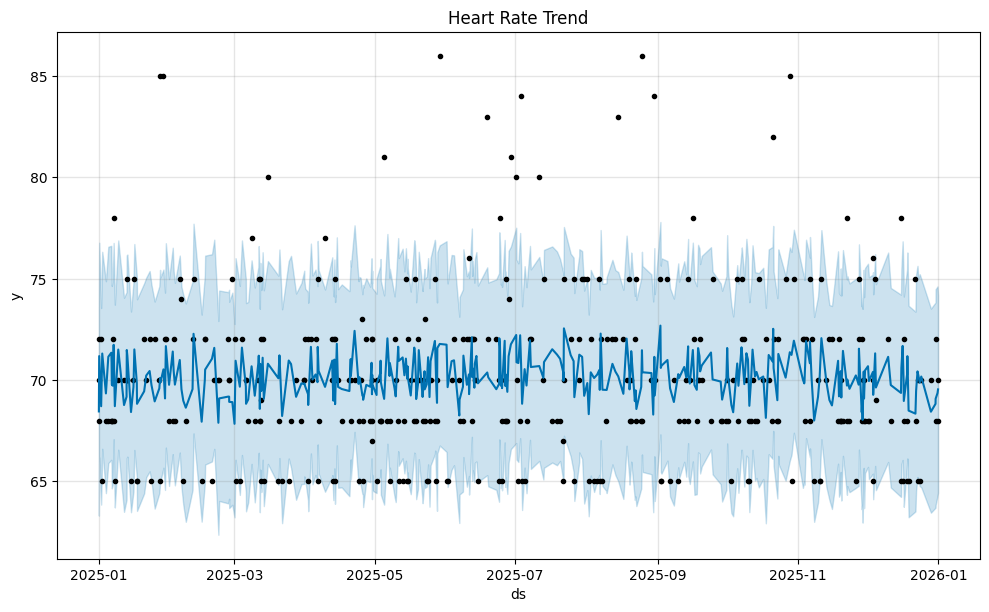

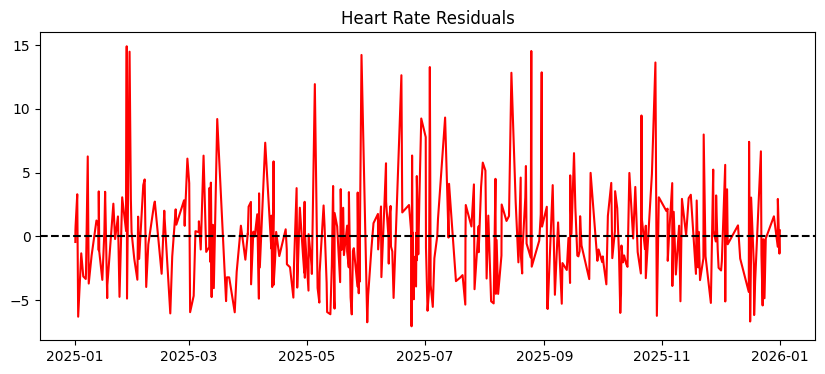

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


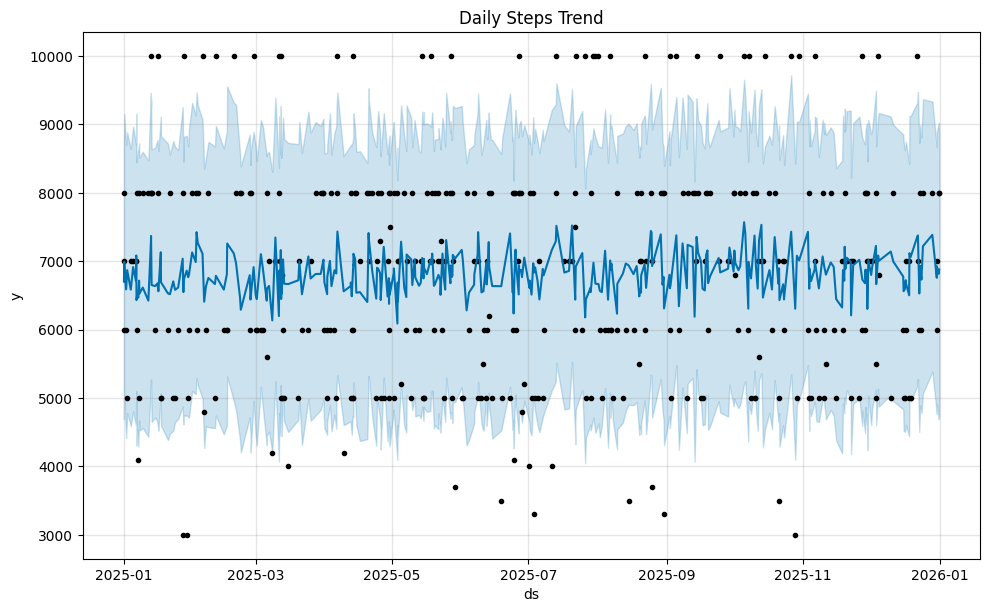

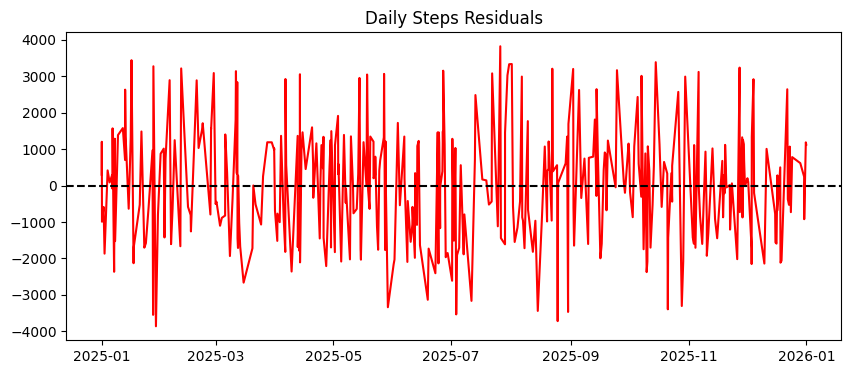

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


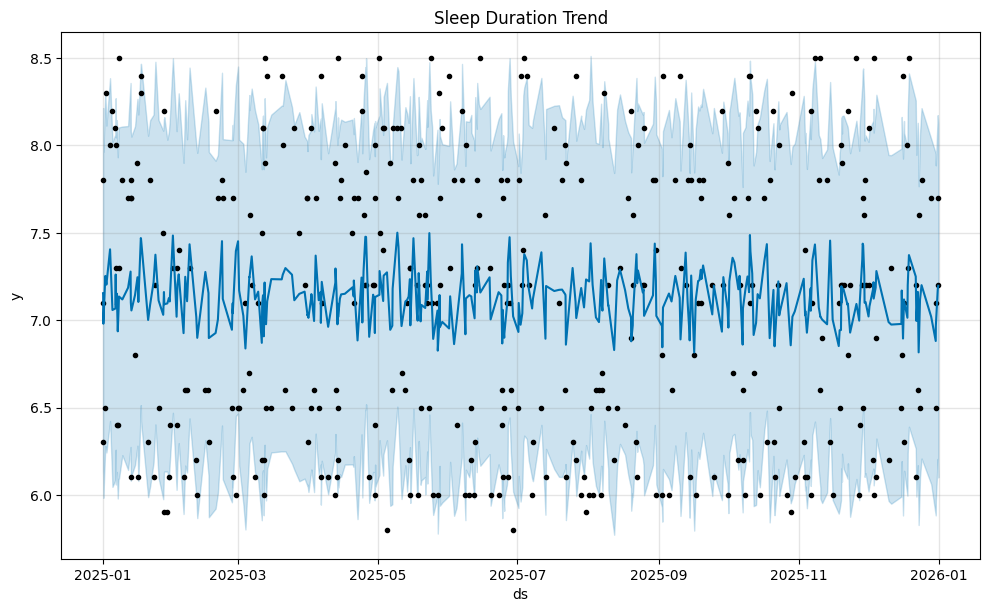

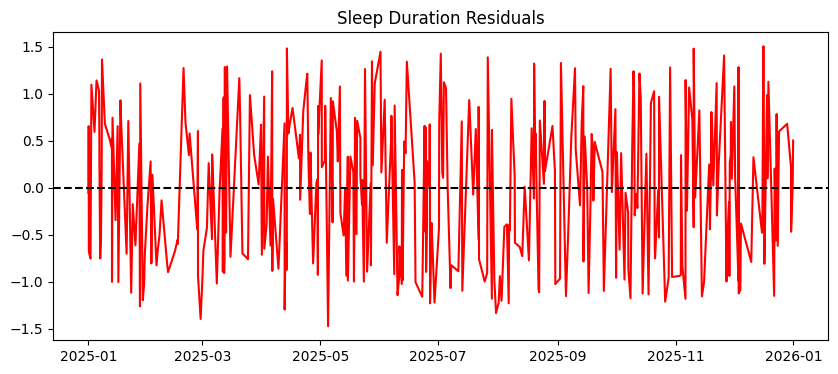

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


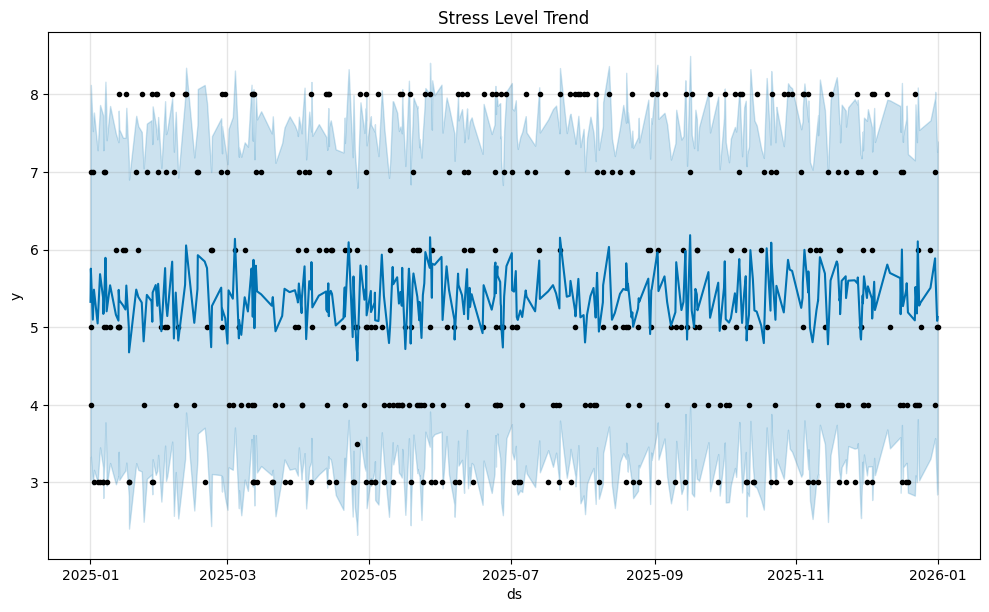

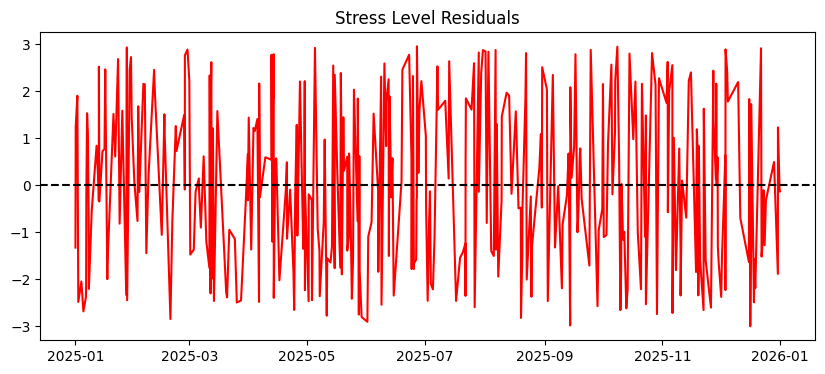

In [183]:
residuals = {}
for col in ts_cols:
    residuals[col] = run_prophet_with_residuals(df_encoded, col)


In [184]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)


In [185]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)


Explained Variance Ratio: [0.55317062 0.2347042 ]


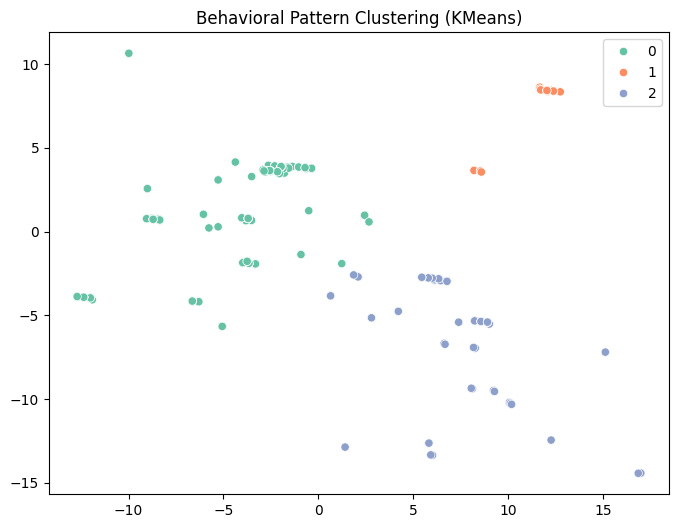

In [186]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=kmeans_labels,
    palette='Set2'
)
plt.title("Behavioral Pattern Clustering (KMeans)")
plt.show()


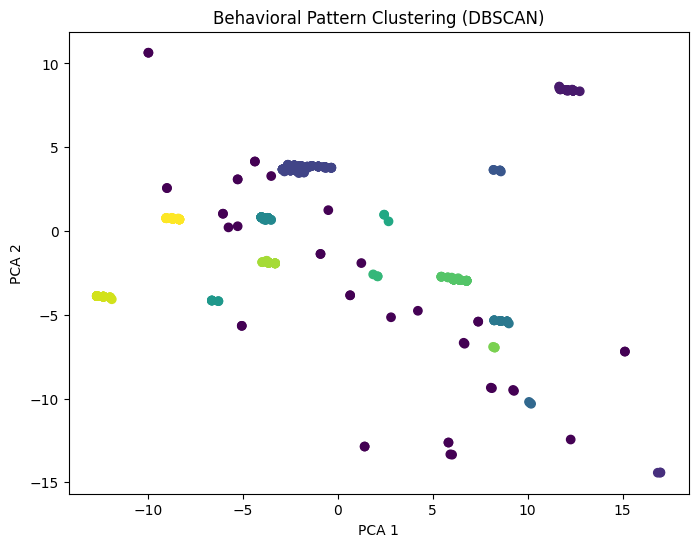

In [187]:
dbscan = DBSCAN(eps=0.6, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_pca)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Behavioral Pattern Clustering (DBSCAN)")
plt.show()
